In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
PATH = 'slooze_challenge./'

sales     = pd.read_csv(PATH + 'SalesFINAL12312016.csv')
purchases = pd.read_csv(PATH + 'PurchasesFINAL12312016.csv')
prices    = pd.read_csv(PATH + '2017PurchasePricesDec.csv')
abc       = pd.read_csv(PATH + 'abc_classified_products.csv')

sales['SalesDate'] = pd.to_datetime(sales['SalesDate'], format='mixed')
purchases['PODate']        = pd.to_datetime(purchases['PODate'])
purchases['ReceivingDate'] = pd.to_datetime(purchases['ReceivingDate'])

print('loaded. abc categories:', abc['ABC'].value_counts().to_dict())

loaded. abc categories: {'C': 5239, 'B': 1444, 'A': 975}


In [4]:
demand = (
    sales.groupby('Brand')
    .agg(annual_demand=('SalesQuantity','sum'),
         annual_revenue=('SalesDollars','sum'))
    .reset_index()
)

unit_cost = prices.groupby('Brand')['PurchasePrice'].median().reset_index()
unit_cost.columns = ['Brand','unit_cost']

purchases['lead_days'] = (purchases['ReceivingDate'] - purchases['PODate']).dt.days
lead_time = (
    purchases[purchases['lead_days'] >= 0] 
    .groupby('Brand')
    .agg(avg_lead_days=('lead_days','mean'),
         std_lead_days=('lead_days','std'))
    .reset_index()
)

daily_demand = (
    sales.groupby(['Brand','SalesDate'])
    ['SalesQuantity'].sum()
    .reset_index()
    .groupby('Brand')['SalesQuantity']
    .std()
    .reset_index()
)
daily_demand.columns = ['Brand','daily_demand_std']

eoq_df = (
    demand
    .merge(unit_cost, on='Brand', how='left')
    .merge(lead_time,  on='Brand', how='left')
    .merge(daily_demand, on='Brand', how='left')
    .merge(abc[['Brand','ABC']], on='Brand', how='left')
)

eoq_df.dropna(subset=['unit_cost','annual_demand'], inplace=True)
eoq_df = eoq_df[eoq_df['annual_demand'] > 0]

print(f'{len(eoq_df)} products with sufficient data for EOQ')
eoq_df.head()

7658 products with sufficient data for EOQ


,Brand,annual_demand,annual_revenue,unit_cost,avg_lead_days,std_lead_days,daily_demand_std,ABC
0,58,288,3741.12,9.28,7.758389,2.066625,4.366215,B
1,60,124,1358.76,7.40,7.659794,2.657092,2.542964,C
2,61,24,335.76,10.60,8.115385,2.084743,0.000000,C
3,62,162,6552.38,28.67,7.331570,2.241460,2.623322,B
4,63,131,5552.69,30.46,7.324427,2.099279,2.609785,B


In [5]:
S = 50
holding_pct = 0.20

eoq_df['holding_cost'] = eoq_df['unit_cost'] * holding_pct
eoq_df['EOQ'] = np.sqrt(2 * eoq_df['annual_demand'] * S / eoq_df['holding_cost'])
eoq_df['EOQ'] = eoq_df['EOQ'].round().astype(int)

eoq_df['orders_per_year'] = (eoq_df['annual_demand'] / eoq_df['EOQ']).round(1)

eoq_df['total_inv_cost'] = (
    (eoq_df['annual_demand'] / eoq_df['EOQ']) * S +
    (eoq_df['EOQ'] / 2) * eoq_df['holding_cost']
).round(2)

print(eoq_df.groupby('ABC')[['EOQ','orders_per_year','total_inv_cost']].mean().round(1))

       EOQ  orders_per_year  total_inv_cost
ABC                                        
A    296.4              5.1           509.9
B    161.1              inf             inf
C     49.4              0.8            78.1


In [7]:
z = 1.65

eoq_df['avg_daily_demand'] = eoq_df['annual_demand'] / 365
eoq_df['daily_demand_std'] = eoq_df['daily_demand_std'].fillna(eoq_df['avg_daily_demand'] * 0.3)
eoq_df['avg_lead_days']    = eoq_df['avg_lead_days'].fillna(eoq_df['avg_lead_days'].median())
eoq_df['std_lead_days']    = eoq_df['std_lead_days'].fillna(0)

eoq_df['safety_stock'] = (
    z * np.sqrt(
        eoq_df['avg_lead_days'] * eoq_df['daily_demand_std']**2 +
        eoq_df['avg_daily_demand']**2 * eoq_df['std_lead_days']**2
    )
).round().astype(int)

eoq_df['reorder_point'] = (
    eoq_df['avg_daily_demand'] * eoq_df['avg_lead_days'] + eoq_df['safety_stock']
).round().astype(int)

print('Avg reorder points by ABC tier:')
print(eoq_df.groupby('ABC')[['safety_stock','reorder_point','EOQ']].mean().round(1))

Avg reorder points by ABC tier:
     safety_stock  reorder_point    EOQ
ABC                                    
A           131.8          165.7  296.4
B            38.6           47.1  161.1
C            10.9           12.0   49.4


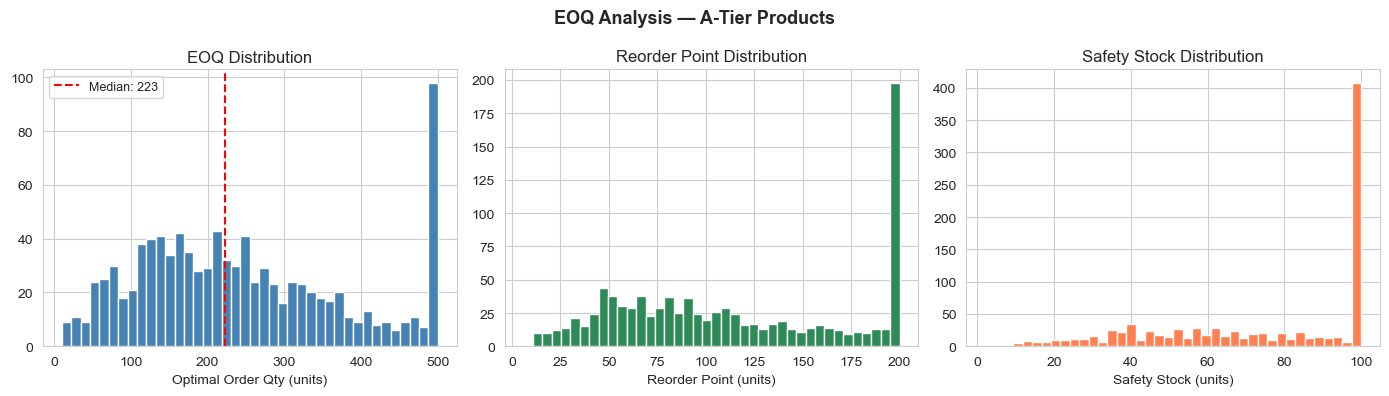

In [8]:
a_items = eoq_df[eoq_df['ABC'] == 'A'].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('EOQ Analysis — A-Tier Products', fontsize=13, fontweight='bold')

axes[0].hist(a_items['EOQ'].clip(0, 500), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('EOQ Distribution')
axes[0].set_xlabel('Optimal Order Qty (units)')
axes[0].axvline(a_items['EOQ'].median(), color='red', linestyle='--',
                label=f"Median: {a_items['EOQ'].median():.0f}")
axes[0].legend(fontsize=9)

axes[1].hist(a_items['reorder_point'].clip(0, 200), bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('Reorder Point Distribution')
axes[1].set_xlabel('Reorder Point (units)')

axes[2].hist(a_items['safety_stock'].clip(0, 100), bins=40, color='coral', edgecolor='white')
axes[2].set_title('Safety Stock Distribution')
axes[2].set_xlabel('Safety Stock (units)')

plt.tight_layout()
plt.savefig('plot_eoq_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

A items below reorder point at year end: 47 / 975


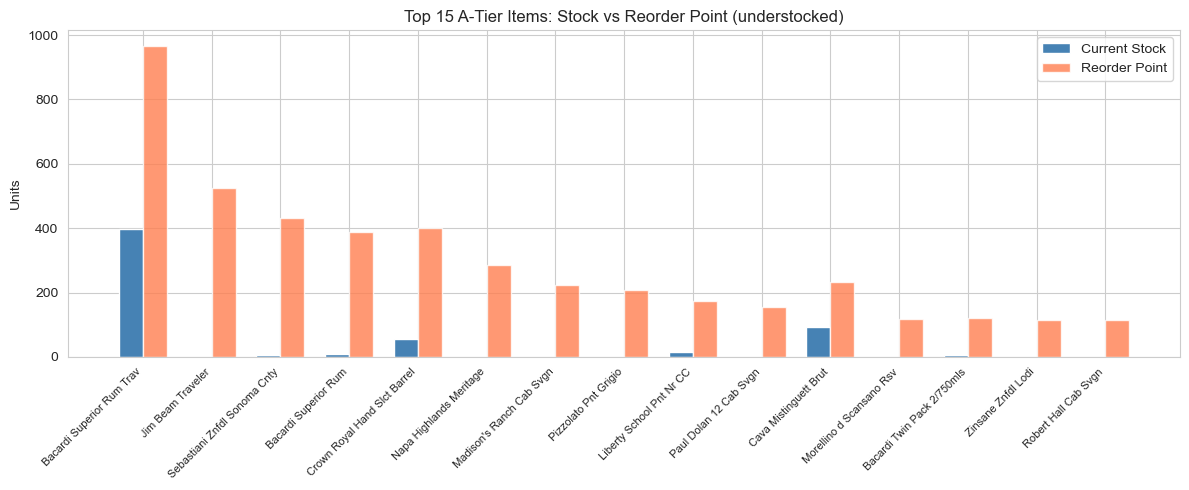

In [9]:
end_inv = pd.read_csv(PATH + 'EndInvFINAL12312016.csv')
end_stock = end_inv.groupby('Brand')['onHand'].sum().reset_index()
end_stock.columns = ['Brand','end_stock']

a_items = a_items.merge(
    abc[['Brand','Description']], on='Brand', how='left'
).merge(end_stock, on='Brand', how='left')

a_items['end_stock'] = a_items['end_stock'].fillna(0)
a_items['below_rop'] = a_items['end_stock'] < a_items['reorder_point']
a_items['stock_gap'] = a_items['reorder_point'] - a_items['end_stock']

print(f"A items below reorder point at year end: {a_items['below_rop'].sum()} / {len(a_items)}")

understocked = a_items[a_items['below_rop']].nlargest(15, 'stock_gap')

fig, ax = plt.subplots(figsize=(12, 5))
labels = [d[:30] + '...' if len(str(d)) > 30 else str(d) for d in understocked['Description']]
x = np.arange(len(labels))
w = 0.35

ax.bar(x - w/2, understocked['end_stock'], w, label='Current Stock', color='steelblue')
ax.bar(x + w/2, understocked['reorder_point'], w, label='Reorder Point', color='coral', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_title('Top 15 A-Tier Items: Stock vs Reorder Point (understocked)')
ax.set_ylabel('Units')
ax.legend()
plt.tight_layout()
plt.savefig('plot_understocked_items.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
cols = ['Brand','ABC','annual_demand','unit_cost','EOQ','orders_per_year',
        'avg_lead_days','safety_stock','reorder_point','total_inv_cost']
eoq_df.merge(abc[['Brand','Description']], on='Brand', how='left')[['Description'] + cols]\
    .sort_values(['ABC','annual_demand'], ascending=[True, False])\
    .to_csv('eoq_reorder_table.csv', index=False)

print('saved eoq_reorder_table.csv')
print('\nSample A-tier rows:')
print(eoq_df[eoq_df['ABC']=='A'][cols].head(5).to_string(index=False))

saved eoq_reorder_table.csv

Sample A-tier rows:
 Brand ABC  annual_demand  unit_cost  EOQ  orders_per_year  avg_lead_days  safety_stock  reorder_point  total_inv_cost
    77   A            908      10.39  209              4.3       7.292162            65             83          434.38
   115   A            623      21.37  121              5.1       7.402730            57             70          516.02
   126   A           1968      20.14  221              8.9       7.726301           200            242          890.34
   171   A            510      36.76   83              6.1       7.664959            41             52          612.34
   273   A            612      17.31  133              4.6       7.498127            48             61          460.30
